In [2]:
import pandas as pd

In [3]:
# 비지도학습-클러스터링
# 비슷한 것 끼리 묶기

# 클러스터링 중 k-means
# k개의 중심점을 임의로 잡음
# 모든 데이터 포인트를 가장 가까운 중심점에 할당

In [4]:
customer_join = pd.read_csv('data/customer_join.csv')
customer_join.shape

(4192, 23)

In [ ]:
# 고객 정보 : 2가지, 고객 자체 정보(일간, 주간), 고객 행동 정보(이용 횟수, 정기 루틴, 가입기간)
customer_clustering = customer_join[['mean_x','median_x','max_x','min_x','membership_period']]
customer_clustering.head(2)

,mean_x,median_x,max_x,min_x,membership_period
0,4.833333,5.0,8,2,47
1,5.083333,5.0,7,3,47


In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [7]:
sc = StandardScaler()
customer_clustering_sc = sc.fit_transform(customer_clustering)


In [8]:
customer_clustering_sc[0]

array([-0.28120614, -0.13367635,  0.08117747, -0.5336197 ,  2.03402524])

In [9]:
kmeans = KMeans(n_clusters=4, random_state=0)
clusters = kmeans.fit(customer_clustering_sc)

In [10]:
customer_clustering['cluster'] = clusters.labels_
customer_clustering['cluster'].unique()

array([2, 1, 0, 3], dtype=int32)

In [11]:
customer_clustering.columns = ['월평균값','월중앙값','월최댓값','월최솟값','회원기간','cluster']
customer_clustering.head()

,월평균값,월중앙값,월최댓값,월최솟값,회원기간,cluster
0,4.833333,5.0,8,2,47,2
1,5.083333,5.0,7,3,47,2
2,4.583333,5.0,6,3,47,2
3,4.833333,4.5,7,2,47,2
4,3.916667,4.0,6,1,47,2


In [15]:
customer_clustering.to_csv('./data/customer_clustering.csv',index=False)

In [12]:
profile = customer_clustering.groupby('cluster').mean().round(2)
profile['인원'] = customer_clustering.groupby('cluster').size()
profile

,월평균값,월중앙값,월최댓값,월최솟값,회원기간,인원
cluster,,,,,,
0,5.54,5.39,8.76,2.70,14.86,1334
1,3.07,2.90,4.78,1.65,9.28,771
2,4.68,4.67,7.23,2.15,36.92,1249
3,8.06,8.05,10.01,6.18,7.02,838


In [ ]:
profile['페르소나'] = [
    '보통 회원기간. 보통 이용',
    '짧은 회원기간. 낮은 이용 (탈퇴 위험)',
    '긴 회원기간. 보통 이용 (안정 단골)',
    '짧은 회원기간. 높은 이용 (신규, 의욕)' 
]

In [14]:
profile

,월평균값,월중앙값,월최댓값,월최솟값,회원기간,인원,페르소나
cluster,,,,,,,
0,5.54,5.39,8.76,2.70,14.86,1334,보통 회원기간. 보통 이용
1,3.07,2.90,4.78,1.65,9.28,771,짧은 회원기간. 낮은 이용 (탈퇴 위험)
2,4.68,4.67,7.23,2.15,36.92,1249,긴 회원기간. 보통 이용 (안정 단골)
3,8.06,8.05,10.01,6.18,7.02,838,"짧은 회원기간. 높은 이용 (신규, 의욕)"


In [16]:
from sklearn.decomposition import PCA

In [17]:
X = customer_clustering_sc
pca = PCA(n_components=2)
# pca.fit(X)
# x_pca = pca.transform(X)
x_pca = pca.fit_transform(X)
type(x_pca)

numpy.ndarray

In [19]:
pca_df = pd.DataFrame(x_pca)
pca_df.head()

,0,1
0,-0.819982,1.959097
1,-0.707922,1.799857
2,-1.061499,1.659826
3,-1.160764,1.810139
4,-2.017132,1.670101


In [20]:
pca_df.shape


(4192, 2)

In [21]:
pca_df['cluster'] = customer_clustering['cluster']


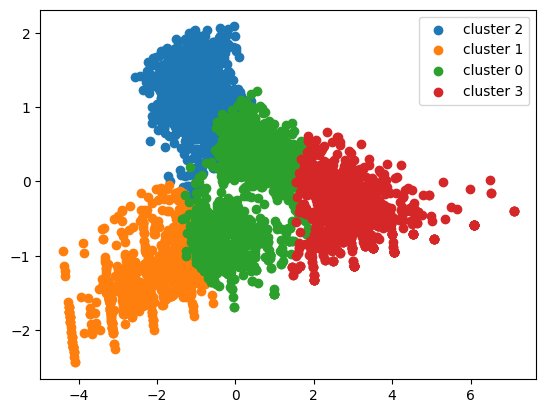

In [23]:
import matplotlib.pyplot as plt

for i in customer_clustering['cluster'].unique():
    tmp = pca_df.loc[pca_df['cluster']==i]
    plt.scatter(tmp[0], tmp[1],label = f'cluster {i}')
    
plt.legend()
plt.show()

# k-means : 군집 -> 몇 개로 분류해야 하는지는 사람이 정해야 한다. 
## 성능지표: 분류개수가 적절한지 -> 지수
### -1~1 범위로 측정: 0.5 이상(매우좋음), 0.25~0.5 (적당함)

In [24]:
from sklearn.metrics import silhouette_score

score = silhouette_score(customer_clustering_sc, customer_clustering['cluster'])
print('실루엣 점수:',score)

실루엣 점수: 0.3723530060583293
